#Assignment Tasks: 
Task 1 – Data Import & Setup 
● Load dataset using Pandas 
● Explore structure: head(), tail(), shape, columns 
● Convert InvoiceDate to datetime 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel(r"C:\Users\jraja\OneDrive\Documents\Assignment\Online Retail.xlsx")
df

print("First 5 Rows:")
print(df.head())

print("\nLast 5 Rows:")
print(df.tail())

print("\nShape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("\nUpdated Data Types:")
print(df.dtypes)

First 5 Rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

Last 5 Rows:
       InvoiceNo StockCode                      Description  Quantity  \
541904    581587     22613      PACK OF 20 SPACEBOY NAPKINS        12   
541905    58158

#Task 2 – Data Cleaning 
● Handle missing values (remove null CustomerID) 
● Remove duplicates 
● Fix invalid values (negative quantity, invalid price)

In [ ]:
import pandas as pd

df = pd.read_excel(r"C:\Users\jraja\OneDrive\Documents\Assignment\Online Retail.xlsx")

print("Initial Shape:", df.shape)
print(df.info())

df = df.dropna(subset=['CustomerID'])

df = df.drop_duplicates()

df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

print("Final Shape:", df.shape)
print(df.isnull().sum())
print(df.head())

df = df.reset_index(drop=True)

print(df.describe())


Initial Shape: (541909, 8)
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB
None
Final Shape: (392692, 8)
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HAN

#Task 3 – Feature Engineering 
● Create TotalPrice = Quantity × UnitPrice 
● Extract time features (Year, Month, Day, Hour) 
● Create categories (Customer Segment, Order Size, Day Type) 

In [4]:
import pandas as pd
df = pd.read_excel(r"C:\Users\jraja\OneDrive\Documents\Assignment\Online Retail.xlsx")

df = df.dropna(subset=['CustomerID'])
df = df.drop_duplicates()
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()


customer_spend = df.groupby('CustomerID')['TotalPrice'].sum()

df['CustomerSegment'] = pd.qcut(
    df['CustomerID'].map(customer_spend),
    q=3,
    labels=['Low', 'Medium', 'High']
)


def order_size(q):
    if q <= 10:
        return 'Small'
    elif q <= 50:
        return 'Medium'
    else:
        return 'Large'

df['OrderSize'] = df['Quantity'].apply(order_size)

df['DayType'] = df['DayOfWeek'].apply(
    lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday'
)

print(df.head())
print(df.columns)
print(df[['TotalPrice', 'Year', 'Month', 'Hour',
          'CustomerSegment', 'OrderSize', 'DayType']].head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  \
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom       15.30   
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34   
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom       22.00   
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34   
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34   

   Year  Month  Day  Hour  DayOfWeek CustomerSegment OrderSize  DayType  
0  2010     12    1     8  Wednesday

#Task 4 – Data Exploration 
● Use describe() and dataset overview 
● Analyze categories (value_counts(), unique()) 
● Perform groupby() (country, month, product) 

In [8]:
import pandas as pd

df = pd.read_excel(r"C:\Users\jraja\OneDrive\Documents\Assignment\Online Retail.xlsx")
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract Month for grouping
df['Month'] = df['InvoiceDate'].dt.month


print("Dataset Shape:", df.shape)
print("\nColumn Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

# Country distribution
print("\nTop Countries by Transactions:")
print(df['Country'].value_counts().head(10))

# Unique products
print("\nNumber of Unique Products:")
print(df['StockCode'].nunique())

# Most sold products
print("\nTop 10 StockCodes:")
print(df['StockCode'].value_counts().head(10))

# Unique customers
print("\nUnique Customers:")
print(df['CustomerID'].nunique())

# Invoice analysis
print("\nUnique Invoices:")
print(df['InvoiceNo'].nunique())

# Sales by Country
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
print("\nSales by Country:")
print(country_sales.head(10))

# Sales by Month
monthly_sales = df.groupby('Month')['TotalPrice'].sum()
print("\nMonthly Sales:")
print(monthly_sales)

# Top Products by Revenue
product_sales = df.groupby('StockCode')['TotalPrice'].sum().sort_values(ascending=False)
print("\nTop Products by Revenue:")
print(product_sales.head(10))

# Average order value by country
avg_order_country = df.groupby('Country')['TotalPrice'].mean().sort_values(ascending=False)
print("\nAverage Order Value by Country:")
print(avg_order_country.head(10))

Dataset Shape: (541909, 10)

Column Info:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
 8   TotalPrice   541909 non-null  float64       
 9   Month        541909 non-null  int32         
dtypes: datetime64[us](1), float64(3), int32(1), int64(1), object(3), str(1)
memory usage: 39.3+ MB
None

Summary Statistics:
            Quantity                 InvoiceDate      UnitPrice  \
count  541909.000000                      541909  541909.000000  

#Task 5 – Data Wrangling 
● Aggregate data using groupby() 
● Sort to find the top customers and countries 
● Restructure data if needed 

In [9]:
import pandas as pd

df = pd.read_excel(r"C:\Users\jraja\OneDrive\Documents\Assignment\Online Retail.xlsx")

# Basic cleaning (safe reuse from Task 2)
df = df.dropna(subset=['CustomerID'])
df = df.drop_duplicates()
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Create TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract Month for analysis
df['Month'] = df['InvoiceDate'].dt.month

# Total sales by customer
customer_sales = df.groupby('CustomerID')['TotalPrice'].sum()

# Total quantity purchased by customer
customer_quantity = df.groupby('CustomerID')['Quantity'].sum()

# Combine into a single dataframe
customer_summary = pd.DataFrame({
    'TotalSales': customer_sales,
    'TotalQuantity': customer_quantity
})

print("\nCustomer Summary (Top 5):")
print(customer_summary.head())

top_customers = customer_summary.sort_values(by='TotalSales', ascending=False)

print("\nTop 10 Customers by Revenue:")
print(top_customers.head(10))

country_sales = df.groupby('Country')['TotalPrice'].sum()
country_orders = df.groupby('Country')['InvoiceNo'].nunique()

country_summary = pd.DataFrame({
    'TotalSales': country_sales,
    'TotalOrders': country_orders
})

top_countries = country_summary.sort_values(by='TotalSales', ascending=False)

print("\nTop Countries by Revenue:")
print(top_countries.head(10))

product_sales = df.groupby('StockCode')['TotalPrice'].sum()

top_products = product_sales.sort_values(ascending=False)

print("\nTop 10 Products by Revenue:")
print(top_products.head(10))

# Monthly sales by country (pivot table)
pivot_country_month = pd.pivot_table(
    df,
    values='TotalPrice',
    index='Country',
    columns='Month',
    aggfunc='sum',
    fill_value=0
)

print("\nPivot Table: Country vs Month Sales")
print(pivot_country_month.head())

customer_monthly = pd.pivot_table(
    df,
    values='TotalPrice',
    index='CustomerID',
    columns='Month',
    aggfunc='sum',
    fill_value=0
)

print("\nCustomer Monthly Spending (Top 5):")
print(customer_monthly.head())


Customer Summary (Top 5):
            TotalSales  TotalQuantity
CustomerID                           
12346.0       77183.60          74215
12347.0        4310.00           2458
12348.0        1797.24           2341
12349.0        1757.55            631
12350.0         334.40            197

Top 10 Customers by Revenue:
            TotalSales  TotalQuantity
CustomerID                           
14646.0      280206.02         196915
18102.0      259657.30          64124
17450.0      194390.79          69973
16446.0      168472.50          80997
14911.0      143711.17          80240
12415.0      124914.53          77374
14156.0      117210.08          57768
17511.0       91062.38          64549
16029.0       80850.84          40108
12346.0       77183.60          74215

Top Countries by Revenue:
                 TotalSales  TotalOrders
Country                                 
United Kingdom  7285024.644        16646
Netherlands      285446.340           94
EIRE             265262.460   

#Task 6 – Statistical Analysis 
● Analyze Quantity, UnitPrice, TotalPrice 
● Calculate mean, median, and mode 
● Find standard deviation, variance, and percentiles 

In [2]:
import pandas as pd
import numpy as np

df = pd.read_excel(r"C:\Users\jraja\OneDrive\Documents\Assignment\Online Retail.xlsx")

# Create TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

cols = ['Quantity', 'UnitPrice', 'TotalPrice']

print("\n CENTRAL TENDENCY")

for col in cols:
    print(f"\n--- {col} ---")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])


print("\n SPREAD (VARIATION)")

for col in cols:
    print(f"\n--- {col} ---")
    print("Standard Deviation:", df[col].std())
    print("Variance:", df[col].var())


print("\n PERCENTILES")

percentiles = [0.25, 0.50, 0.75, 0.90, 0.95]

for col in cols:
    print(f"\n--- {col} ---")
    print(df[col].quantile(percentiles))

print("\n SUMMARY STATISTICS")
print(df[cols].describe())


 CENTRAL TENDENCY

--- Quantity ---
Mean: 9.55224954743324
Median: 3.0
Mode: 1

--- UnitPrice ---
Mean: 4.611113626088514
Median: 2.08
Mode: 1.25

--- TotalPrice ---
Mean: 17.987794876999644
Median: 9.75
Mode: 15.0

 SPREAD (VARIATION)

--- Quantity ---
Standard Deviation: 218.08115785023386
Variance: 47559.391409298616

--- UnitPrice ---
Standard Deviation: 96.75985306117937
Variance: 9362.469164421023

--- TotalPrice ---
Standard Deviation: 378.8108235059747
Variance: 143497.64000527473

 PERCENTILES

--- Quantity ---
0.25     1.0
0.50     3.0
0.75    10.0
0.90    24.0
0.95    29.0
Name: Quantity, dtype: float64

--- UnitPrice ---
0.25    1.25
0.50    2.08
0.75    4.13
0.90    7.95
0.95    9.95
Name: UnitPrice, dtype: float64

--- TotalPrice ---
0.25     3.40
0.50     9.75
0.75    17.40
0.90    31.80
0.95    59.40
Name: TotalPrice, dtype: float64

 SUMMARY STATISTICS
            Quantity      UnitPrice     TotalPrice
count  541909.000000  541909.000000  541909.000000
mean        9.5

Task 7 – Data Visualization (Min 8 Plots) 
Matplotlib: 
● Line chart 
● Bar chart 
● Histogram 
● Box plot 
Seaborn: 
● Count plot 
● Violin plot 
● Heatmap 
● Pair plot

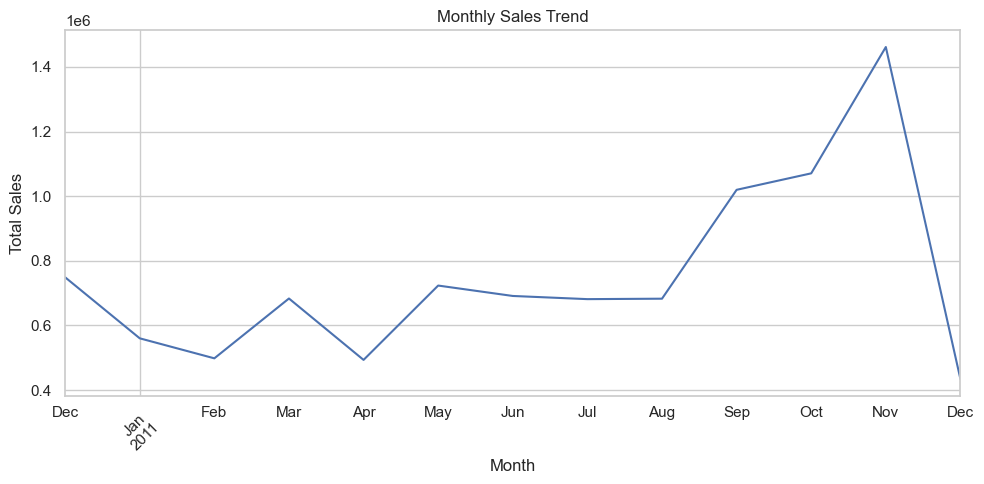

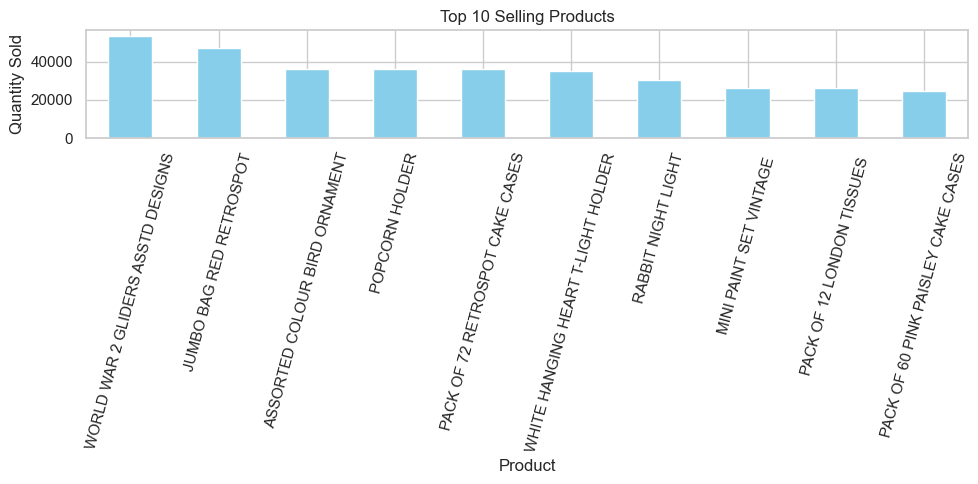

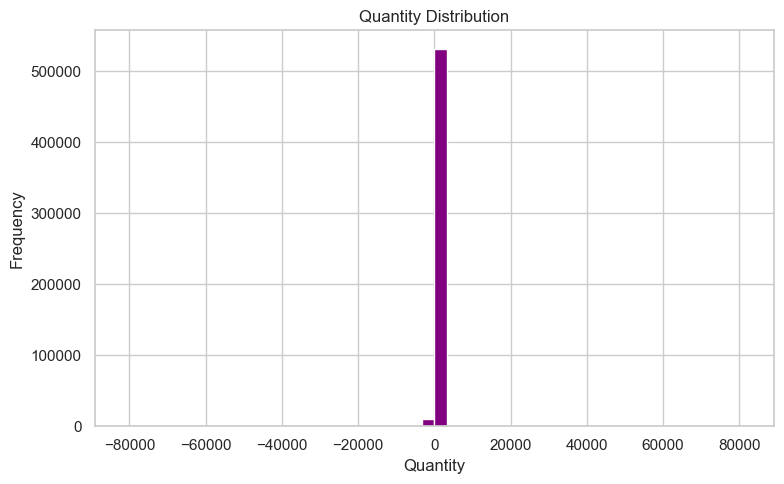

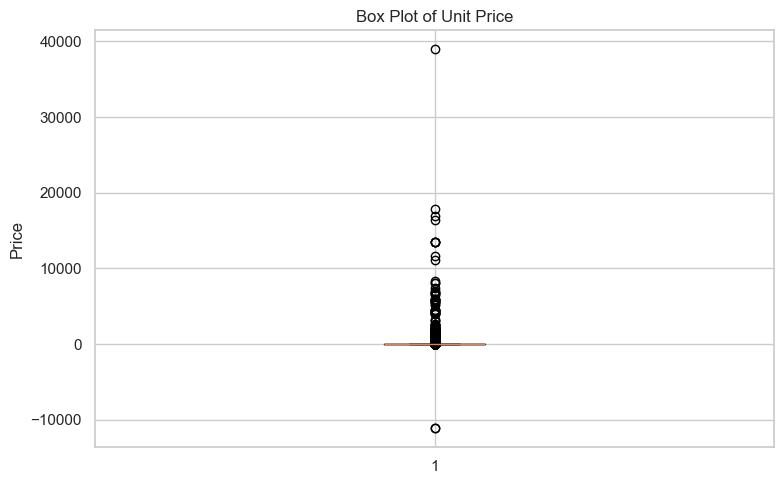

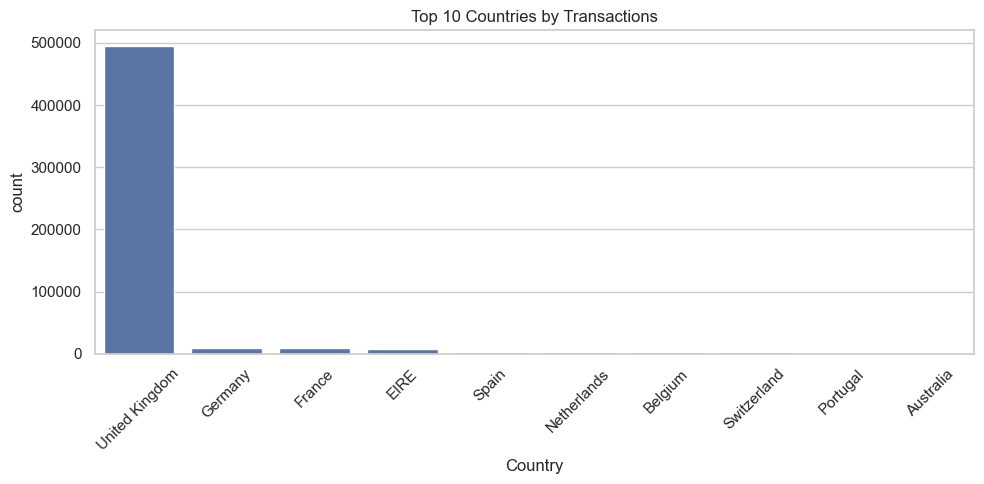

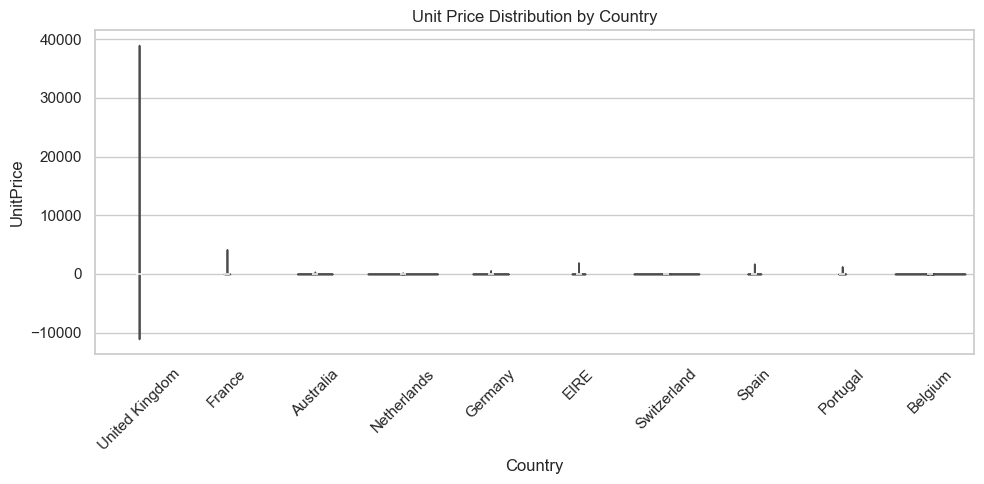

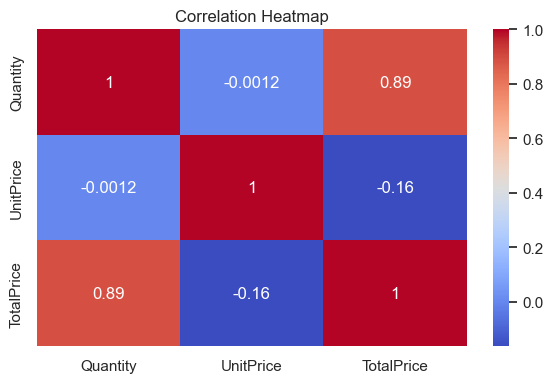

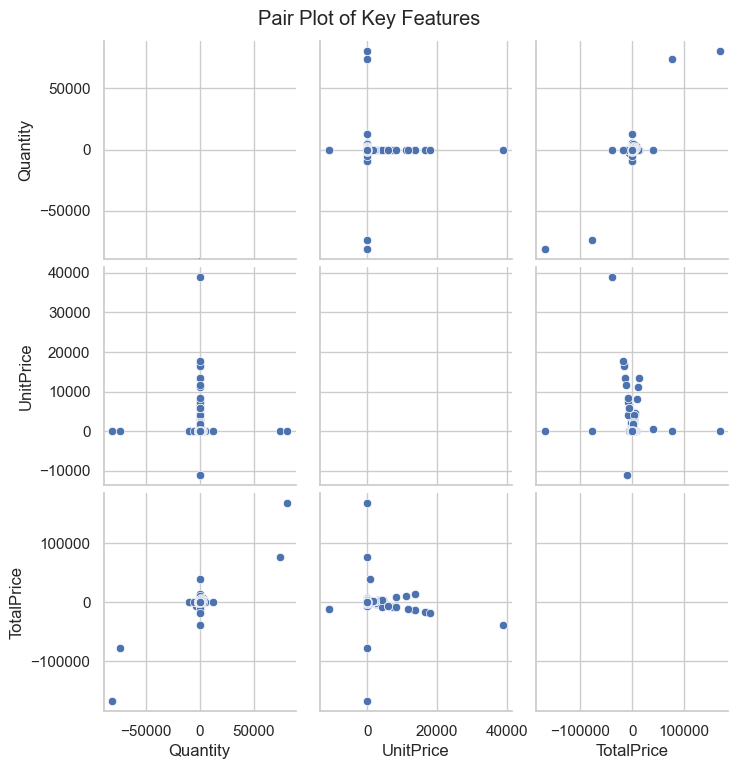

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Cleaned Dataset
df = pd.read_excel(r"C:\Users\jraja\OneDrive\Documents\Assignment\Online Retail.xlsx")

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create additional useful columns
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# MATPLOTLIB PLOTS

# 1. Line Chart
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Bar Chart
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar', color='skyblue')
plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

# 3. Histogram
plt.figure(figsize=(8,5))
plt.hist(df['Quantity'], bins=50, color='purple')
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 4. Box Plot – Unit Price
plt.figure(figsize=(8,5))
plt.boxplot(df['UnitPrice'])
plt.title("Box Plot of Unit Price")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# SEABORN PLOTS

# 5. Count Plot
top_countries = df['Country'].value_counts().head(10).index
filtered_df = df[df['Country'].isin(top_countries)]
plt.figure(figsize=(10,5))
sns.countplot(data=filtered_df, x='Country', order=top_countries)
plt.title("Top 10 Countries by Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6. Violin Plot
plt.figure(figsize=(10,5))
sns.violinplot(data=filtered_df, x='Country', y='UnitPrice')
plt.title("Unit Price Distribution by Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7. Heatmap – Correlation Matrix
corr = df[['Quantity', 'UnitPrice', 'TotalPrice']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# 8. Pair Plot
sns.pairplot(df[['Quantity', 'UnitPrice', 'TotalPrice']])
plt.suptitle("Pair Plot of Key Features", y=1.02)
plt.show()


Task 8 – Business Insights 
● Identify: 
○ Top country 
○ Best sales month 
○ Peak sales time 
● Analyze: 
○ Customer behavior 
○ High-value customers 
○ Top products 

In [9]:
import pandas as pd

df = pd.read_excel(r"C:\Users\jraja\OneDrive\Documents\Assignment\Online Retail.xlsx")

# Convert date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Feature Engineering
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df['Hour'] = df['InvoiceDate'].dt.hour

# 1. Top Country
top_country = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(1)

# 2. Best Sales Month
best_month = df.groupby('Month')['TotalPrice'].sum().sort_values(ascending=False).head(1)

# 3. Peak Sales Time (Hour)
peak_hour = df.groupby('Hour')['TotalPrice'].sum().sort_values(ascending=False).head(1)

print("===== KEY INSIGHTS =====")
print("\nTop Country by Sales:\n", top_country)
print("\nBest Sales Month:\n", best_month)
print("\nPeak Sales Hour:\n", peak_hour)

# 4. Customer Behavior
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()
customer_spending = df.groupby('CustomerID')['TotalPrice'].sum()

print("\n===== CUSTOMER BEHAVIOR =====")
print("\nAverage Orders per Customer:", round(customer_orders.mean(), 2))
print("Average Spending per Customer:", round(customer_spending.mean(), 2))

# 5. High-Value Customers (Top 10)
high_value_customers = customer_spending.sort_values(ascending=False).head(10)

print("\n===== HIGH-VALUE CUSTOMERS =====")
print(high_value_customers)

# 6. Top Products
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

print("\n===== TOP PRODUCTS =====")
print(top_products)

===== KEY INSIGHTS =====

Top Country by Sales:
 Country
United Kingdom    8187806.364
Name: TotalPrice, dtype: float64

Best Sales Month:
 Month
2011-11    1461756.25
Freq: M, Name: TotalPrice, dtype: float64

Peak Sales Hour:
 Hour
12    1362484.29
Name: TotalPrice, dtype: float64

===== CUSTOMER BEHAVIOR =====

Average Orders per Customer: 5.08
Average Spending per Customer: 1898.46

===== HIGH-VALUE CUSTOMERS =====
CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187482.17
14911.0    132572.62
12415.0    123725.45
14156.0    113384.14
17511.0     88125.38
16684.0     65892.08
13694.0     62653.10
15311.0     59419.34
Name: TotalPrice, dtype: float64

===== TOP PRODUCTS =====
Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53847
JUMBO BAG RED RETROSPOT               47363
ASSORTED COLOUR BIRD ORNAMENT         36381
POPCORN HOLDER                        36334
PACK OF 72 RETROSPOT CAKE CASES       36039
WHITE HANGING HEART T-LIGHT HOLDER    35317
RABBIT NIGHT LIGHT   